# 第二階段:聚焦單一傳球 play(snap → pass 片段)

**最終目標**:做一個「傳球空間分析」工具,給教練或球探使用。

**本階段只做一件事**:挑**一個**傳球 play,從 tracking 抓出「發球(ball_snap)到傳球(pass_forward)」之間的畫面,整理成乾淨、看得懂的資料,為後續的「空間計算」打基礎。

我們**還不會**做任何空間量化(例如最近防守者距離、控制區),那是下一階段的事。這一階段的重點是:**先把一個 play 的片段切乾淨、確認每一列是誰在做什麼。**

---

### 為什麼要切「snap 到 pass」這段?

- **ball_snap(發球)**:play 真正開始的瞬間,22 位球員就定位。
- **pass_forward(往前傳)**:四分衛把球丟出去的瞬間。
- 這中間的幾秒,就是接球員跑路線、防守員盯人、四分衛找空檔的過程。**「傳球空間」就發生在這段時間裡**,所以我們先把它單獨切出來。

## 步驟 0:載入工具與設定路徑

- **輸入**:無
- **輸出**:`pandas`、資料夾路徑設定、示範用的 `gameId`
- **目的**:準備好後面每一步會用到的工具與路徑,跟第一階段一樣。

In [1]:
import sys
from pathlib import Path

import pandas as pd

# 讓筆記本找得到上一層資料夾裡的 config.py
sys.path.append(str(Path.cwd().parent))
from config import DATA_DIR, SAMPLE_GAME_ID

print("pandas 版本:", pd.__version__)
print("原始資料夾:", DATA_DIR)
print("示範用的 gameId:", SAMPLE_GAME_ID)

pandas 版本: 2.2.3
原始資料夾: /Users/jingleliao/Downloads/nfl-big-data-bowl-regional-event-data-main/data
示範用的 gameId: 2021090900


## 步驟 1:挑一個傳球 play

- **輸入**:`plays.csv`
- **輸出**:我們要分析的 `SAMPLE_PLAY_ID`,以及它的基本資訊
- **目的**:選定一個**傳球成功**的 play 當範例。這裡用第一階段小練習那個 `playId=137`(DAL 進攻、TB 防守,Prescott 深傳左路),因為它傳球成功、畫面完整。

> `passResult` 代表傳球結果:`C`=傳球成功、`I`=沒接到、`S`=被擒殺、`IN`=被抄截、`R`=QB 自己跑。

In [2]:
SAMPLE_PLAY_ID = 137

plays = pd.read_csv(DATA_DIR / "plays.csv")

# 用 gameId + playId 定位唯一一個 play
this_play = plays[(plays["gameId"] == SAMPLE_GAME_ID) & (plays["playId"] == SAMPLE_PLAY_ID)]

print("挑中的 play:")
print(this_play[[
    "gameId", "playId", "possessionTeam", "defensiveTeam",
    "down", "yardsToGo", "passResult",
]].to_string(index=False))

print("\n文字描述:")
print(this_play["playDescription"].iloc[0])

挑中的 play:
    gameId  playId possessionTeam defensiveTeam  down  yardsToGo passResult
2021090900     137            DAL            TB     1         10          C

文字描述:
(13:18) (Shotgun) D.Prescott pass deep left to A.Cooper pushed ob at DAL 30 for 28 yards (A.Winfield).


## 步驟 2:從 tracking 篩出這一個 play

- **輸入**:`tracking/tracking_<gameId>.csv`
- **輸出**:DataFrame `play_track`(只含這一個 play 的所有 frame、所有球員 + 球)
- **目的**:整場 tracking 很大(上面第一階段看到約 9 萬列),我們只要**這一個 play** 的畫面。

**一列代表什麼?** 一列 = 這個 play 裡、某位球員(或球)、在某個時間點(frameId)的位置。

> `nflId` 空白(NaN)的那一列代表那是**球**,不是球員。

In [3]:
tracking_file = DATA_DIR / "tracking" / f"tracking_{SAMPLE_GAME_ID}.csv"
tracking = pd.read_csv(tracking_file)

# 用 gameId + playId 篩出單一 play
play_track = tracking[
    (tracking["gameId"] == SAMPLE_GAME_ID) & (tracking["playId"] == SAMPLE_PLAY_ID)
].copy()

print("play_track 形狀 (列數, 欄數):", play_track.shape)
print("總共有幾個時間點 (frame):", play_track["frameId"].nunique())
print("球員列數:", play_track["nflId"].notna().sum(), "/ 球的列數:", play_track["nflId"].isna().sum())
play_track.head()

play_track 形狀 (列數, 欄數): (851, 16)
總共有幾個時間點 (frame): 37
球員列數: 814 / 球的列數: 37


,gameId,playId,nflId,frameId,time,jerseyNumber,team,playDirection,x,y,s,a,dis,o,dir,event
989,2021090900,137,35441.0,1,2021-09-10T00:28:09Z,93.0,TB,left,106.92,20.83,0.07,0.08,0.01,153.18,250.65,NaN
990,2021090900,137,35441.0,2,2021-09-10T00:28:10Z,93.0,TB,left,106.90,20.83,0.11,0.08,0.02,153.92,266.05,NaN
991,2021090900,137,35441.0,3,2021-09-10T00:28:10Z,93.0,TB,left,106.96,20.99,0.61,0.88,0.17,153.92,14.93,NaN
992,2021090900,137,35441.0,4,2021-09-10T00:28:10Z,93.0,TB,left,107.02,21.09,0.86,0.70,0.11,153.92,23.73,NaN
993,2021090900,137,35441.0,5,2021-09-10T00:28:10Z,93.0,TB,left,107.08,21.17,0.98,0.63,0.11,153.92,29.26,NaN


## 步驟 3:找出關鍵時間點(snap 與 pass 的 frameId)

- **輸入**:`play_track` 的 `event` 欄位
- **輸出**:`snap_frame`、`pass_frame` 兩個 frameId
- **目的**:在 `event` 欄位裡找 `ball_snap`(發球)和 `pass_forward`(傳球)分別發生在**第幾個 frame**。

> 先把這個 play 出現過的所有事件標籤列出來,**用資料本身確認**,不要憑印象。

In [4]:
# 這個 play 出現過哪些事件、各自在哪個 frame(一個 frame 所有球員共用同一個 event)
events = (
    play_track.dropna(subset=["event"])[["frameId", "event"]]
    .drop_duplicates()
    .sort_values("frameId")
)
print("=== 這個 play 的事件時間軸 ===")
print(events.to_string(index=False))

# 取出 snap 與 pass 的 frameId(取第一個符合的)
snap_frame = play_track.loc[play_track["event"] == "ball_snap", "frameId"].iloc[0]
pass_frame = play_track.loc[play_track["event"] == "pass_forward", "frameId"].iloc[0]

print("\nball_snap 在 frame:", snap_frame)
print("pass_forward 在 frame:", pass_frame)
# tracking 每 0.1 秒一個 frame,所以 (pass - snap) * 0.1 就是秒數
print("snap 到 pass 經過:", round((pass_frame - snap_frame) * 0.1, 1), "秒")

=== 這個 play 的事件時間軸 ===
 frameId              event
       6 autoevent_ballsnap
       7          ball_snap
      32       pass_forward

ball_snap 在 frame: 7
pass_forward 在 frame: 32
snap 到 pass 經過: 2.5 秒


## 步驟 4:切出「snap 到 pass」這段區間

- **輸入**:`play_track`、`snap_frame`、`pass_frame`
- **輸出**:DataFrame `dropback`(只含 snap 到 pass 之間的畫面)
- **目的**:只保留這兩個 frame **之間(含頭尾)** 的畫面,這就是我們要分析「空間」的那幾秒。

In [5]:
dropback = play_track[
    (play_track["frameId"] >= snap_frame) & (play_track["frameId"] <= pass_frame)
].copy()

print("dropback 形狀 (列數, 欄數):", dropback.shape)
print("涵蓋的 frame 範圍:", dropback["frameId"].min(), "→", dropback["frameId"].max())
print("共幾個 frame:", dropback["frameId"].nunique())
# 每個 frame 應該都是 22 位球員 + 1 顆球 = 23 列
print("\n每個 frame 的列數(應該一致):")
print(dropback.groupby("frameId").size().value_counts())

dropback 形狀 (列數, 欄數): (598, 16)
涵蓋的 frame 範圍: 7 → 32
共幾個 frame: 26

每個 frame 的列數(應該一致):
23    26
Name: count, dtype: int64


## 步驟 5:補上人名與角色(讓每一列看得懂)

- **輸入**:`dropback`、`players.csv`、`pffScoutingData.csv`
- **輸出**:DataFrame `dropback_named`
- **目的**:tracking 只有 `nflId`(編號),看不出是誰、在做什麼。我們把它:
  - 接上 `players` → 得到 `displayName`(人名)、`officialPosition`(位置)
  - 接上 `pff` → 得到 `pff_role`(這個 play 的角色:跑路線 / 防守 / 保護 / 衝傳)

> 球那一列(`nflId` 是空的)接不到球員資料是正常的,人名欄位會是空白。

In [6]:
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")

# 這個 play 的 pff 標記(每位球員一列)
play_pff = pff[
    (pff["gameId"] == SAMPLE_GAME_ID) & (pff["playId"] == SAMPLE_PLAY_ID)
][["nflId", "pff_role", "pff_positionLinedUp"]]

# 用 nflId 接人名與位置
dropback_named = dropback.merge(
    players[["nflId", "displayName", "officialPosition"]], on="nflId", how="left"
)
# 再用 nflId 接 pff 角色
dropback_named = dropback_named.merge(play_pff, on="nflId", how="left")

print("dropback_named 形狀:", dropback_named.shape)

# 看 snap 當下這一格,22 位球員各是誰、什麼角色
snap_moment = dropback_named[dropback_named["frameId"] == snap_frame]
print("\n=== 發球(snap)當下的 22 位球員 ===")
print(
    snap_moment[snap_moment["nflId"].notna()][
        ["team", "displayName", "officialPosition", "pff_role", "x", "y"]
    ].sort_values(["team", "pff_role"]).to_string(index=False)
)

dropback_named 形狀: (598, 20)

=== 發球(snap)當下的 22 位球員 ===
team         displayName officialPosition   pff_role      x     y
 DAL        Dak Prescott               QB       Pass 113.19 23.64
 DAL         Tyron Smith                T Pass Block 109.62 20.42
 DAL       La'el Collins                T Pass Block 109.86 26.61
 DAL     Connor Williams                G Pass Block 109.40 22.10
 DAL     Connor McGovern                G Pass Block 109.02 24.98
 DAL       Tyler Biadasz                C Pass Block 109.23 24.06
 DAL        Amari Cooper               WR Pass Route 109.37 13.79
 DAL     Ezekiel Elliott               RB Pass Route 110.11 44.07
 DAL        Blake Jarwin               TE Pass Route 109.98 35.44
 DAL      Dalton Schultz               TE Pass Route 109.16 31.37
 DAL         CeeDee Lamb               WR Pass Route 109.42  7.46
  TB       Lavonte David              ILB   Coverage 103.74 20.86
  TB     Shaquil Barrett              OLB   Coverage 104.75 33.84
  TB       Carlton 

## 步驟 6:畫一張 snap 當下的場上快照

- **輸入**:`snap_moment`(snap 那一格)
- **輸出**:一張散點圖(球員在球場上的位置)
- **目的**:用肉眼確認資料是對的 — 進攻方與防守方分站攻防線兩側、位置分佈合理。**先看得懂,再進到空間計算。**

> 這裡用 matplotlib 畫。若尚未安裝,下一格會提示;可先略過這步,不影響前面的資料。
> `x` 是球場長邊(0–120 碼),`y` 是短邊(0–53.3 碼)。進攻方、防守方、球用不同顏色標示。

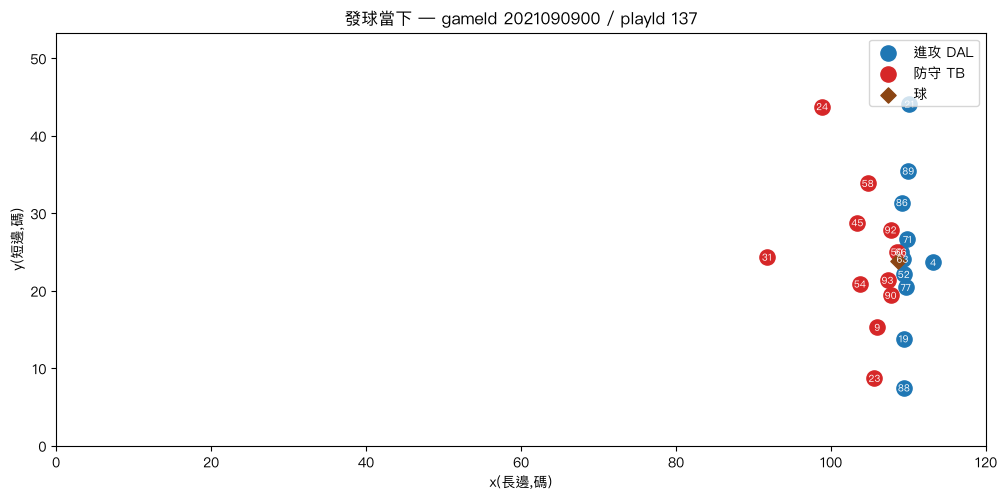

In [7]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("尚未安裝 matplotlib,先略過這張圖(不影響前面的資料)。")
    print("要畫圖的話,在終端機執行:")
    print("  .venv/bin/python -m pip install matplotlib")
else:
    # 設定中文字型,避免標題/圖例/軸標籤顯示成方框(macOS 內建 PingFang TC)
    plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    plt.rcParams["axes.unicode_minus"] = False

    offense_team = this_play["possessionTeam"].iloc[0]
    defense_team = this_play["defensiveTeam"].iloc[0]

    players_now = snap_moment[snap_moment["nflId"].notna()]
    ball_now = snap_moment[snap_moment["nflId"].isna()]
    off = players_now[players_now["team"] == offense_team]
    deff = players_now[players_now["team"] == defense_team]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(off["x"], off["y"], s=120, c="tab:blue", label=f"進攻 {offense_team}", zorder=3)
    ax.scatter(deff["x"], deff["y"], s=120, c="tab:red", label=f"防守 {defense_team}", zorder=3)
    ax.scatter(ball_now["x"], ball_now["y"], s=60, c="saddlebrown", marker="D", label="球", zorder=4)

    # 標上球衣背號,方便對照
    for _, r in players_now.iterrows():
        ax.annotate(int(r["jerseyNumber"]), (r["x"], r["y"]),
                    ha="center", va="center", fontsize=7, color="white", zorder=5)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.set_xlabel("x(長邊,碼)")
    ax.set_ylabel("y(短邊,碼)")
    ax.set_title(f"發球當下 — gameId {SAMPLE_GAME_ID} / playId {SAMPLE_PLAY_ID}")
    ax.legend(loc="upper right")
    ax.set_aspect("equal")
    plt.show()

## 本階段完成了什麼

- 選定一個傳球成功的 play(`playId=137`)。
- 從整場 tracking 篩出這一個 play 的所有畫面。
- 用 `event` 欄位找出 `ball_snap` 與 `pass_forward` 的 frame,**用資料驗證**而非憑印象。
- 切出「snap → pass」這段 `dropback` 片段。
- 把編號接上人名、位置、角色,讓每一列看得懂是誰在做什麼。
- 畫出 snap 當下的場上快照,肉眼確認資料正確。

**下一階段(等你確認理解後再開始)**:在這個片段上開始量化「空間」 — 例如每位接球員與最近防守者的距離隨時間怎麼變化,之後再往控制區(Voronoi)等更完整的空間指標推進。